Classificatore basato su SVM lineari e word embedding.
 Il terzo classificatore dovrà utilizzare una rappresentazione vettoriale del
testo costruita a partire da word embedding. I modelli di embedding da
utilizzare potranno essere, ad esempio, quelli forniti dal sito ItaliaNLP
Lab(per
l’italiano:
embeddings/,
http://www.italianlp.it/resources/italian-word
per
l’inglese:
http://www.italianlp.it/t2k-resources/en/w2v/ukwac/ukwac128.sqlite). In
questo caso si richiede di:
  testare diverse rappresentazioni del testo che variano rispetto al modo
di combinare gli embedding delle singole parole e/o rispetto alle
categorie grammaticali delle parole prese in considerazione;
  valutare i vari modelli sul validation set;
  testare sul test set il sistema che ha ottenuto le migliori prestazioni
nella fase di validazione.

we : vettori di parole che rappresentano semantica parole

documento è aggregazione di embedding



In [1]:
# preprocessing
# ottendo il file degli embedding in formato txt
# import sqlite3
# dim = 128

# sql_path = f'ukwac{dim}.sqlite'
# txt_path = f'ukwac{dim}.txt'

# con = sqlite3.connect(sql_path)

# cur = con.cursor()

# cur = con.cursor()

In [2]:
import numpy as np
import os

In [3]:
class Document:

    def __init__(self, document_path):
        self.document_path = document_path
        self.doc_id = None
        self.split = None
        self.topic = None
        self._load_doc_info(document_path)
        self.tokens = []
        self.features = None
        self.count = None

    # Estraggo le informazioni dal nomed el file
    def _load_doc_info(self, document_path):
        self.doc_id = (document_path.split('.')[0]).split("/")[-1]
        self.split = self.doc_id.split('_')[-1]
        self.autore = self.doc_id.split('_')[0]


    def __str__(self):
        return ' '.join([token.word for token in self.tokens])


class Token:

    def __init__(self, word, pos):
        self.word = word
        self.pos = pos

    def __str__(self):
        return f'Word = {self.word}, POS = {self.pos}'

Caricamento dei we

In [4]:
# Il file contiene una riga per ogni parola,
# con elementi separati da "\t".

# Il primo elemento è la parola, i successivi 32/64/128
# sono le componenti dell'embedding.

embeddings_dim = 128
embeddings_path = f"/content/drive/MyDrive/LC2 progetto/ukwac128.txt"



In [5]:
# Leggiamo il file dei word embeddings e creiamo un dizionario della forma:

# Chiave = parola
# Valore = embedding della parola

def load_word_embeddings(src_path):
    embeddings = dict()
    for line in open(src_path, 'r'):
        line = line.strip().split('\t')
        word = line[0]
        embedding = line[1:]
        embedding = [float(comp) for comp in embedding] # convertiamo le componenti dell'embedding in float
        embeddings[word] = np.asarray(embedding) # trasformiamo la lista delle componenti in un vettore di numpy
    return embeddings

embeddings = load_word_embeddings(embeddings_path)

In [6]:
embeddings['look']

array([-8.11252743e-02,  5.83741218e-02, -9.63585973e-02, -1.30857930e-01,
       -2.20076181e-02,  1.43518850e-01, -1.43217416e-02,  3.69769186e-02,
        4.51061875e-02,  1.94371608e-03, -4.27691489e-02, -6.90320507e-02,
       -3.57395411e-02, -4.75746803e-02,  1.12212030e-03,  1.34233292e-02,
        1.62433330e-02,  7.70728141e-02, -7.56583586e-02, -1.18944272e-01,
        3.06515172e-02,  5.27200773e-02,  3.02098040e-02, -1.43015664e-02,
        2.41367612e-03, -2.45480686e-02,  4.48601358e-02, -4.55513708e-02,
       -4.70575914e-02,  6.05762526e-02,  8.70166942e-02, -7.59472698e-02,
        4.42990325e-02,  9.78138968e-02,  1.53245166e-01,  4.92882244e-02,
        3.55913639e-02, -2.57081296e-02,  7.71935433e-02, -1.16152884e-02,
        4.92800027e-02,  1.74966618e-01, -1.58213302e-02,  3.32453810e-02,
        6.04113825e-02, -8.44025835e-02,  8.27268064e-02, -7.79001508e-04,
        8.33261684e-02, -1.39134884e-01,  6.58671334e-02, -1.92226414e-02,
        1.72582954e-01,  

caricamento dataset

In [7]:
conllu_dir = '/content/drive/MyDrive/LC2 progetto/linguisticProfiling/dataset/'

In [8]:
# # normalizza parole
# Numbers:
# Integer numbers between 0 and 2100 were kept as original
# Each integer number greater than 2100 is mapped in a string which represents the number of digits needed to store the number (ex: 10000 -> DIGLEN_5)
# Each digit in a string that is not convertible to a number must be converted with the following char: @Dg. This is an example of replacement (ex: 10,234 -> @Dg@Dg,@Dg@Dg@Dg)
# Words:
# A string starting with lower case character must be lowercased (e.g.: (“aNtoNio” -> “antonio”), (“cane” -> “cane”))
# A string starting with an upcased character must be capitalized (e.g.: (“CANE” -> “Cane”, “Antonio”-> “Antonio”))

import re

def get_digits(text):
    try:
      val = int(text)
    except:
      text = re.sub(r'\d', '@Dg', text)
      return text
    if val >= 0 and val < 2100:
      return str(val)
    else:
      return "DIGLEN_" + str(len(str(val)))

def normalize_text(word):
    if "http" in word or ("." in word and "/" in word):
      word = str("___URL___")
      return word
    if len(word) > 26:
      return "__LONG-LONG__"
    new_word = get_digits(word)
    if new_word != word:
      word = new_word
    if word[0].isupper():
      word = word.capitalize()
    else:
      word = word.lower()
    return word



In [9]:
def get_tokens_from_file(src_path):
    document_tokens = []
    lines_to_skip = 0
    take_pos = False
    for line in open(src_path, 'r'):
        # print(f'\nRiga: {line.strip()}')
        if line[0].isdigit():
            splitted_line = line.strip().split('\t')
            if '-' in splitted_line[0]:
                # print('Ho trovato un - ')
                skip_ids = splitted_line[0].split('-')
                # print('Indici da saltare', skip_ids)
                lines_to_skip = int(skip_ids[1]) - int(skip_ids[0]) + 1 # l'indice ci indica quali righe saltare
                take_pos = True # booleano che indica che dobbiamo prendere la pos della prossima parola
                word = normalize_text(splitted_line[1])
                pos = splitted_line[3]
                token = Token(word=word, pos=None) # inizializziamo il token con la forma, il pos lo prendiamo nella riga successiva
                # print(f'Preso token {word}')
                document_tokens.append(token)
            else:
                if lines_to_skip == 0:
                    word = normalize_text(splitted_line[1])
                    pos = splitted_line[3]
                    token = Token(word=word, pos=pos)
                    # print(f'Preso token {word}')
                    document_tokens.append(token)
                if take_pos:
                    pos = splitted_line[3]
                    document_tokens[-1].pos = pos
                    take_pos = False
                lines_to_skip = max(0, lines_to_skip-1)
    return document_tokens

In [10]:
lista_documenti = []

for cartella, sottocartelle, files in os.walk(conllu_dir):
    for file in files:
        if file.endswith(".conllu"):
            file_path = cartella+"/"+file
            document = Document(file_path)
            document_tokens = get_tokens_from_file(file_path)
            document.tokens = document_tokens
            lista_documenti.append(document)

In [11]:
print(lista_documenti[0])

I am glad to recollect that when the carrier began to move , my mother ran out at the gate , and called to him to stop , that she might kiss me once more . I am glad to dwell upon the earnestness and love with which she lifted up her face to mine , and did so .


Estrazione features

In [12]:
# prtendo tutti i we di tutto il documento e faccio la media

In [13]:
lista_1 = lista_documenti.copy()
def compute_embeddings_mean(document_embeddings):
    sum_array = np.sum(document_embeddings, axis=0)
    mean_array = np.divide(sum_array, len(document_embeddings))
    return mean_array

In [14]:
# Metodo che calcola la media di tutti i word embeddings di un documento
def compute_all_embeddings_mean(document_tokens):
    document_embeddings = []
    for token in document_tokens:
        word = token.word
        if word in embeddings:
            document_embeddings.append(embeddings[word])

    if len(document_embeddings) == 0:
        mean_document_embeddings = np.zeros(embeddings_dim)
    else:
        mean_document_embeddings = compute_embeddings_mean(document_embeddings)
    return mean_document_embeddings

In [15]:
# Creazione della matrice delle features del training set
# Ogni documento è rappresentato dall'aggregazione dei word
# embeddings delle parole (con la media)

def extract_features(documents):
    for document in documents:
        # document_embeddings = compute_all_embeddings_mean(document.tokens)
        document_embeddings = compute_all_embeddings_mean(document.tokens)
        # document_embeddings = compute_filtered_embeddings_sep_means(document.tokens)
        document.features = document_embeddings




In [16]:
extract_features(lista_1)

lista_1[0].features

array([ 0.02240157, -0.01302712, -0.07086912,  0.00430699, -0.03788988,
        0.05520809, -0.01640698,  0.00666559,  0.0052579 , -0.08044502,
       -0.05493711, -0.08188634, -0.0133598 ,  0.01083473, -0.01593792,
        0.07249122,  0.00647154,  0.0281186 ,  0.08939566, -0.01501688,
       -0.0169758 , -0.01849987, -0.08445805, -0.02645275,  0.00045789,
       -0.04396923, -0.07537316,  0.0441015 , -0.044877  ,  0.022777  ,
        0.05414156, -0.05327623, -0.02200894, -0.10622005, -0.07022555,
        0.03044472,  0.11213498, -0.04586586, -0.06199528, -0.03275609,
       -0.00774199,  0.00216377, -0.0663563 ,  0.08289757, -0.06710473,
       -0.00789908,  0.02026281,  0.04451404, -0.03846463, -0.08327409,
       -0.02634126, -0.03273429,  0.0497392 , -0.02910089,  0.01225123,
        0.02129619,  0.01761625,  0.04211514,  0.01725515, -0.00700801,
        0.0496052 , -0.01783385, -0.06042418, -0.00474901,  0.02705362,
       -0.00181162, -0.03839303,  0.04569228, -0.05741794, -0.02

split train e test e val


In [17]:
def train_test_split(all_documents):
    train_features_dict, train_labels = [], []
    test_features_dict, test_labels = [], []
    val_features_dict, val_labels = [], []

    for document in all_documents:
        if document.split == 'training':
            train_features_dict.append(document.features)
            train_labels.append(document.autore)
        elif document.split == 'validation':
            val_features_dict.append(document.features)
            val_labels.append(document.autore)
        else:
            test_features_dict.append(document.features)
            test_labels.append(document.autore)

    return train_features_dict, train_labels, test_features_dict, test_labels, val_features_dict, val_labels

In [18]:
train_features1, train_labels1, test_features1, test_labels1, val_features1, val_labels1 = train_test_split(lista_1)
len(train_features1), len(train_labels1), len(test_features1), len(test_labels1), len(val_features1), len(val_labels1)

(3000, 3000, 300, 300, 300, 300)

In [19]:
X_train1 = np.array(train_features1)
y_train1 = np.array(train_labels1)
X_test1 = np.array(test_features1)
y_test1 = np.array(test_labels1)
X_val1 = np.array(val_features1)
y_val1 = np.array(val_labels1)


X_train1.shape

(3000, 128)

              precision    recall  f1-score   support

      austen       0.83      0.87      0.85       100
     dickens       0.72      0.76      0.74       100
       woolf       0.78      0.69      0.73       100

    accuracy                           0.77       300
   macro avg       0.77      0.77      0.77       300
weighted avg       0.77      0.77      0.77       300



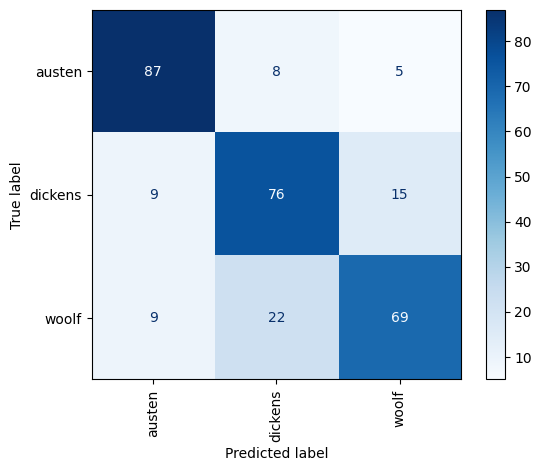

In [20]:
# normalizzazione
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_X_train1 = scaler.fit_transform(X_train1)

# e classificazione
from sklearn.svm import LinearSVC

svc = LinearSVC(dual=False)
svc.fit(scaled_X_train1, y_train1)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

scaled_X_val1 = scaler.transform(X_val1)
val_predictions1 = svc.predict(scaled_X_val1)

print(classification_report(y_val1, val_predictions1,  zero_division=0))
ConfusionMatrixDisplay.from_predictions(val_labels1, val_predictions1, xticks_rotation='vertical', cmap='Blues');

              precision    recall  f1-score   support

      austen       0.79      0.84      0.82       100
     dickens       0.60      0.60      0.60       100
       woolf       0.62      0.58      0.60       100

    accuracy                           0.67       300
   macro avg       0.67      0.67      0.67       300
weighted avg       0.67      0.67      0.67       300



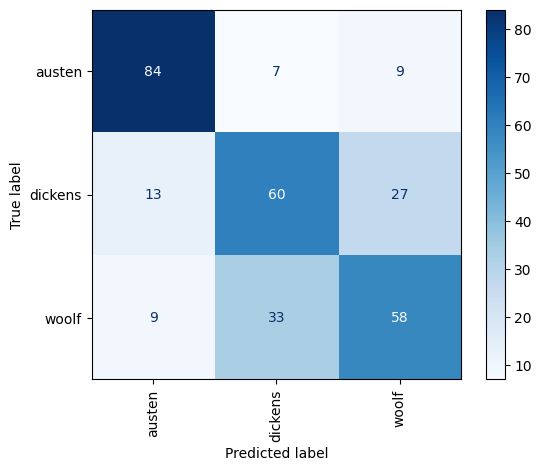

In [21]:
# è il più performante quindi test set
scaled_X_test1 = scaler.transform(X_test1)
test_predictions1 = svc.predict(scaled_X_test1)

print(classification_report(y_test1, test_predictions1,  zero_division=0))
ConfusionMatrixDisplay.from_predictions(test_labels1, test_predictions1, xticks_rotation='vertical', cmap='Blues')

In [22]:
# altro metodo di aggregazione
# Metodo che calcola la media dei word embeddings solo di aggettivi, nomi e verbi.
lista_2 = lista_documenti.copy()
def compute_filtered_embeddings_mean(document_tokens):
    document_embeddings = []

    for token in document_tokens:
        word = token.word
        pos = token.pos
        if word in embeddings and pos in ['ADJ', 'NOUN', 'VERB']:
            document_embeddings.append(embeddings[word])

    if len(document_embeddings) == 0:
        mean_document_embeddings = np.zeros(embeddings_dim)
    else:
        mean_document_embeddings = compute_embeddings_mean(document_embeddings)
    return mean_document_embeddings

In [23]:
def extract_features_filtered(documents):
    for document in documents:
        # document_embeddings = compute_all_embeddings_mean(document.tokens)
        document_embeddings = compute_filtered_embeddings_mean(document.tokens)
        # document_embeddings = compute_filtered_embeddings_sep_means(document.tokens)
        document.features = document_embeddings

extract_features_filtered(lista_2)
lista_2[0].features

array([-0.03603843, -0.01541035, -0.05988833, -0.01466581, -0.0467126 ,
        0.10305132,  0.04180925, -0.03727103, -0.00317518, -0.00536767,
       -0.05779919, -0.06872587, -0.04032756,  0.05308445, -0.00802892,
        0.05199388, -0.03163042,  0.02399055,  0.0858831 ,  0.02100346,
       -0.00477421, -0.06580725,  0.00138634, -0.0445264 ,  0.03285289,
       -0.04595033, -0.02057293,  0.0557883 ,  0.02691689,  0.02754648,
        0.03811793, -0.01981839,  0.0648196 , -0.04287862, -0.02402744,
        0.00340633,  0.10524035, -0.0840914 , -0.00077193, -0.04460334,
       -0.0266511 ,  0.03485754, -0.01823847,  0.11883126, -0.05538927,
       -0.00662029, -0.00182634,  0.02165525, -0.01030326, -0.09134576,
       -0.02915101, -0.01707582,  0.06018904,  0.00609357,  0.04779753,
        0.08728838, -0.00752008,  0.04691523, -0.0025932 ,  0.01629414,
        0.01480759, -0.03666386, -0.00897065, -0.0054294 ,  0.07990238,
       -0.00222968, -0.02641699,  0.04731343, -0.06743227,  0.03

In [24]:
train_features2, train_labels2, test_features2, test_labels2, val_features2, val_labels2 = train_test_split(lista_2)
len(train_features2), len(train_labels2), len(test_features2), len(test_labels2), len(val_features2), len(val_labels2)


(3000, 3000, 300, 300, 300, 300)

In [25]:
X_train2 = np.array(train_features2)
y_train2 = np.array(train_labels2)
X_test2 = np.array(test_features2)
y_test2 = np.array(test_labels2)
X_val2 = np.array(val_features2)
y_val2 = np.array(val_labels2)

              precision    recall  f1-score   support

      austen       0.70      0.79      0.74       100
     dickens       0.63      0.46      0.53       100
       woolf       0.58      0.66      0.62       100

    accuracy                           0.64       300
   macro avg       0.64      0.64      0.63       300
weighted avg       0.64      0.64      0.63       300



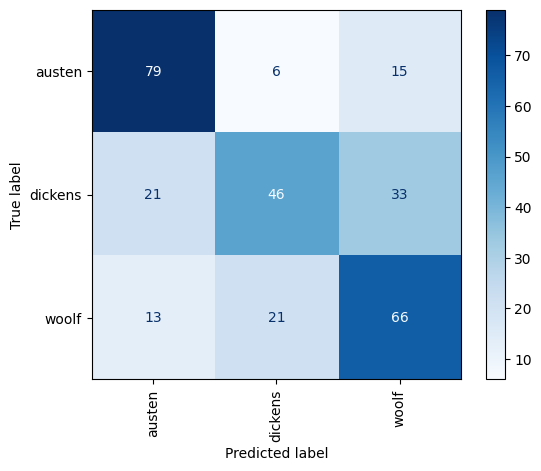

In [26]:
# normalizzazione
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_X_train2 = scaler.fit_transform(X_train2)

# e classificazione
from sklearn.svm import LinearSVC

svc = LinearSVC(dual=False)
svc.fit(scaled_X_train2, y_train2)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

scaled_X_val2 = scaler.transform(X_val2)
val_predictions2 = svc.predict(scaled_X_val2)

print(classification_report(y_val2, val_predictions2,  zero_division=0))
ConfusionMatrixDisplay.from_predictions(val_labels2, val_predictions2, xticks_rotation='vertical', cmap='Blues');

In [27]:
# altro metodo di aggregazione
# Metodo che calcola la media separatamente dei word embedding
# di aggettivi, nomi e verbi, e concatena i 3 vettori ottenuti.
lista_3 = lista_documenti.copy()
def compute_filtered_embeddings_sep_means(document_tokens):
    adj_embeddings = []
    noun_embeddings = []
    verb_embeddings = []

    for token in document_tokens:
        word = token.word
        pos = token.pos
        if word in embeddings and pos in ['ADJ']:
            adj_embeddings.append(embeddings[word])
        elif word in embeddings and pos in ['NOUN']:
            noun_embeddings.append(embeddings[word])
        elif word in embeddings and pos in ['VERB']:
            verb_embeddings.append(embeddings[word])

    if len(adj_embeddings) == 0:
        mean_adj_embeddings = np.zeros(embeddings_dim)
    else:
        mean_adj_embeddings = compute_embeddings_mean(adj_embeddings)

    if len(noun_embeddings) == 0:
        mean_noun_embeddings = np.zeros(embeddings_dim)
    else:
        mean_noun_embeddings = compute_embeddings_mean(noun_embeddings)

    if len(verb_embeddings) == 0:
        mean_verb_embeddings = np.zeros(embeddings_dim)
    else:
        mean_verb_embeddings = compute_embeddings_mean(verb_embeddings)


    mean_document_embeddings = np.concatenate([mean_adj_embeddings, mean_noun_embeddings, mean_verb_embeddings], axis=None)
    return mean_document_embeddings

In [28]:
def extract_features_concatenate(documents):
    for document in documents:
        document_embeddings = compute_filtered_embeddings_sep_means(document.tokens)
        document.features = document_embeddings

In [29]:

extract_features_concatenate(lista_3)

lista_3[0].features

array([-4.49800119e-03,  6.23999611e-02, -1.06750198e-01,  7.13663781e-03,
       -9.12477088e-04,  1.73730180e-01,  1.46591187e-01, -1.82877807e-03,
        2.59833671e-02, -1.94491465e-02,  3.87045881e-03, -2.49249372e-03,
       -1.85056508e-01, -1.21005975e-01, -7.10776895e-02,  7.78541639e-02,
       -6.43980429e-02,  4.32381518e-02,  7.10350424e-02, -1.59655109e-01,
       -6.35644421e-02, -7.05748238e-03, -4.78483029e-02,  2.53327452e-02,
        2.44119421e-01, -4.16117832e-02, -6.03858847e-03,  1.04708858e-01,
        5.37117682e-02,  1.49977021e-03,  2.26821378e-03, -9.54903439e-02,
        1.15723088e-01, -1.22094259e-01, -1.05395526e-01,  1.21478982e-01,
        1.77255273e-01, -9.74330008e-02, -3.03472746e-02, -4.49594557e-02,
       -1.06377691e-01,  7.66106099e-02, -5.57558844e-03,  1.90639928e-01,
       -8.03568512e-02,  7.87121952e-02, -1.04354620e-01,  3.36521678e-02,
        5.22561260e-02, -1.01453476e-01, -5.29658608e-02,  1.63427740e-02,
        1.44265413e-01,  

In [30]:
train_features3, train_labels3, test_features3, test_labels3, val_features3, val_labels3 = train_test_split(lista_3)
len(train_features3), len(train_labels3), len(test_features3), len(test_labels3), len(val_features3), len(val_labels3)


(3000, 3000, 300, 300, 300, 300)

In [31]:
X_train3 = np.array(train_features3)
y_train3 = np.array(train_labels3)
X_test3 = np.array(test_features3)
y_test3 = np.array(test_labels3)
X_val3 = np.array(val_features3)
y_val3 = np.array(val_labels3)

              precision    recall  f1-score   support

      austen       0.71      0.75      0.73       100
     dickens       0.61      0.54      0.57       100
       woolf       0.65      0.68      0.66       100

    accuracy                           0.66       300
   macro avg       0.65      0.66      0.65       300
weighted avg       0.65      0.66      0.65       300



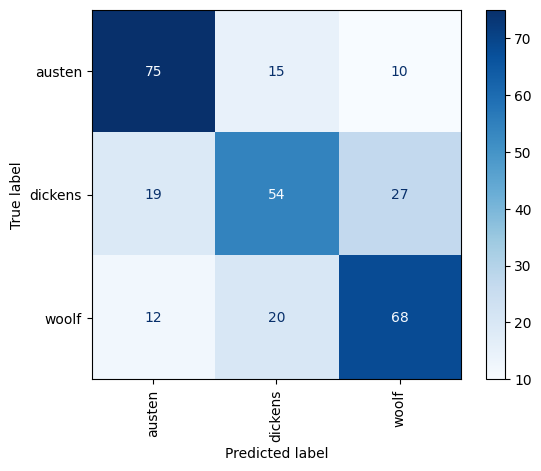

In [32]:
# normalizzazione
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_X_train3 = scaler.fit_transform(X_train3)

# e classificazione
from sklearn.svm import LinearSVC

svc = LinearSVC(dual=False)
svc.fit(scaled_X_train3, y_train3)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

scaled_X_val3 = scaler.transform(X_val3)
val_predictions3 = svc.predict(scaled_X_val3)

print(classification_report(y_val3, val_predictions3,  zero_division=0))
ConfusionMatrixDisplay.from_predictions(val_labels3, val_predictions3, xticks_rotation='vertical', cmap='Blues');